# Classical Gravitational Interactions

The following code block is a list of all functions

In [1]:
import numpy as np
import plotly.express as px
import pandas as pd

def init_objects(R, M, vm):
    objects[i,0:3] = R * np.array((np.random.random(),np.random.random(),np.random.random()))
    objects[i,3] = M * (1 - np.random.random()) #(1-random.random()) since random.random() returns values on the interval [0.0, 1.0)
    objects[i,4:7] = vm * objects[i,3] * np.array((np.random.random(),np.random.random(),np.random.random()))
    
    return(objects)

def force_calculation(objects, N, G, soft_len, t, dt, frame_num):
    #Sets force equal to 0
    objects[:,7:10] = 0
    
    #Records current object position and frame
    if frame_num % frame_skip == 0:
        for i in range(N):
            frames.append((objects[i,0], objects[i,1], objects[i,2], str(i), frame_num/frame_skip))
    
    #Calculating the force between every object
    for i in range(N):
        for j in range(i+1,N):
            if i != j:
                r = objects[j,0:3] - objects[i,0:3]
                r_dot = np.dot(r,r)
                
                F = G * objects[i,3] * objects[j,3] * (r / (r_dot + soft_len**2)**1.5)
                
                objects[i,7:10] += F
                objects[j,7:10] -= F
    
    #Updating momentum
    objects[:,4:7] += objects[:,7:10] * dt
    
    #Updating Position
    for i in range(N): #Put in for loop so that mass is a scalar instead of an array of different shape from momentum. [find better solution?]
        objects[i,0:3] += (objects[i,4:7] / objects[i,3]) * dt
    
    return(frames)

## Circular Elliptical Orbit

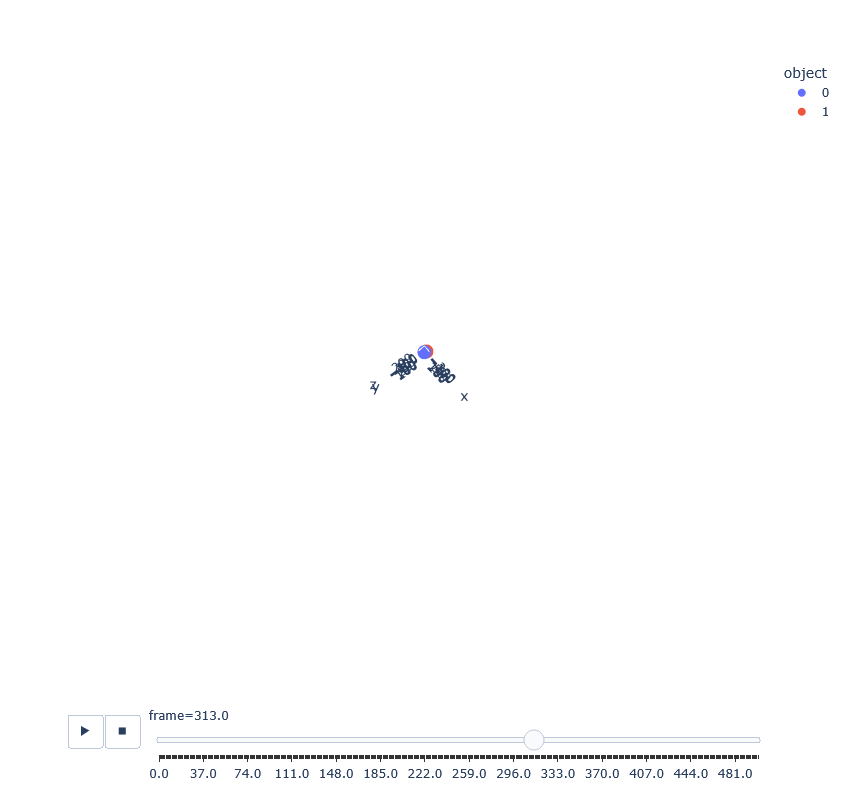

In [5]:
N = 2 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 20

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 5000
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((100,0,0))
objects[1,3] = 1
objects[1,4:7] = np.array((0,7.5,0))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()

## Circular Elliptical Orbit In Non-Unit Planes

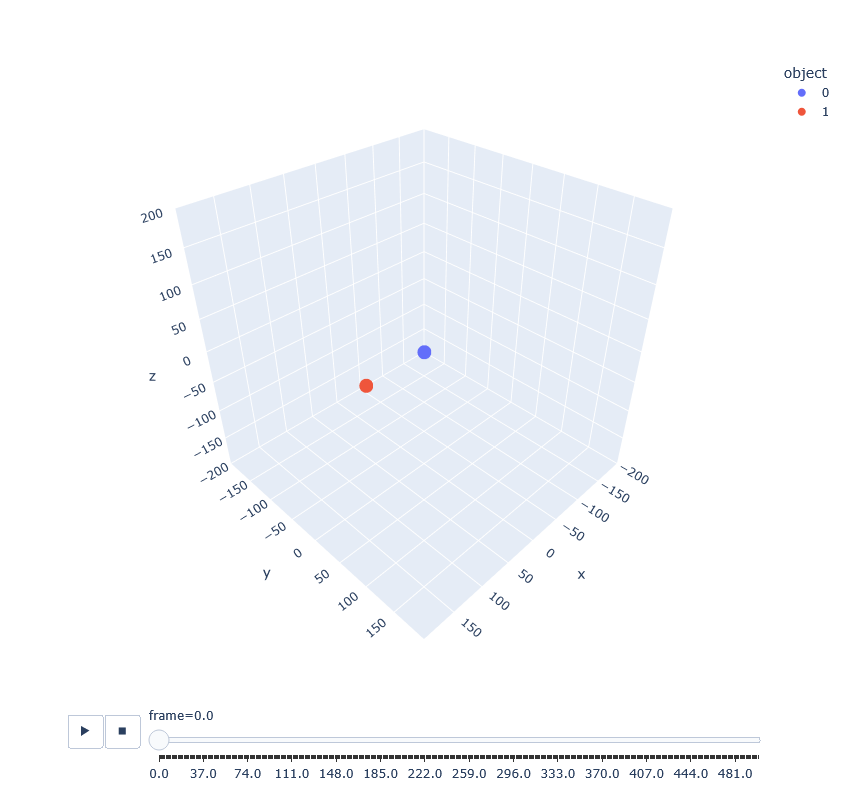

In [33]:
N = 2 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 20

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 5000
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((100,0,0))
objects[1,3] = 1
objects[1,4:7] = np.array((0,28**(0.5),28.25**(0.5)))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()

## Three Body Orbitals

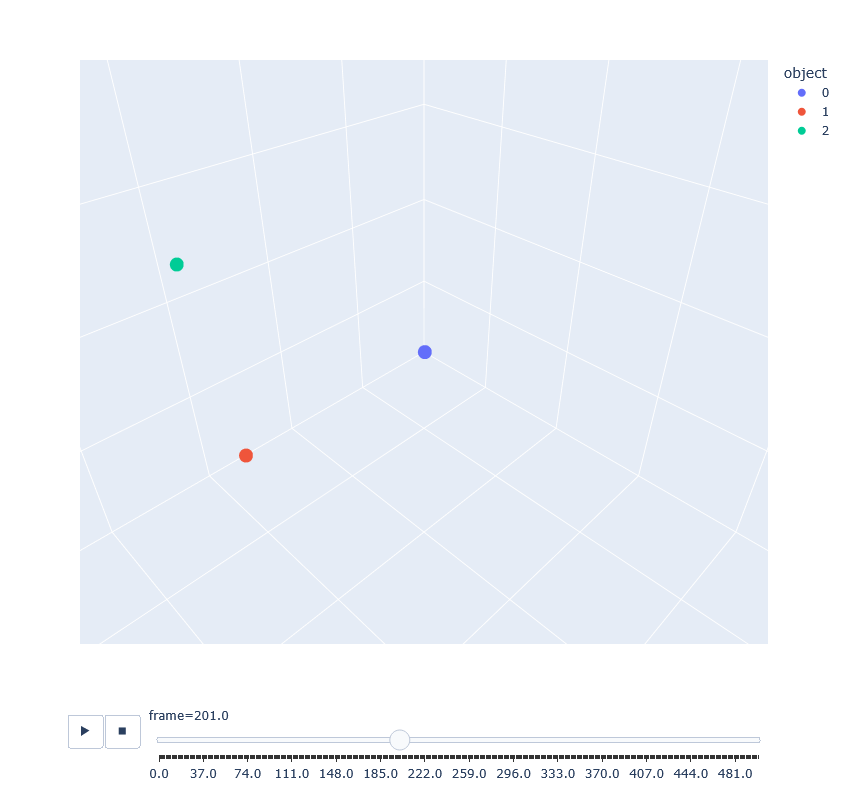

In [34]:
N = 3 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 30

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 5000
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((100,0,0))
objects[1,3] = 1
objects[1,4:7] = np.array((0,28**(0.5),28.25**(0.5)))

objects[2,0:3] = np.array((0,150,0))
objects[2,3] = 1
objects[2,4:7] = np.array((-6,0,0))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()

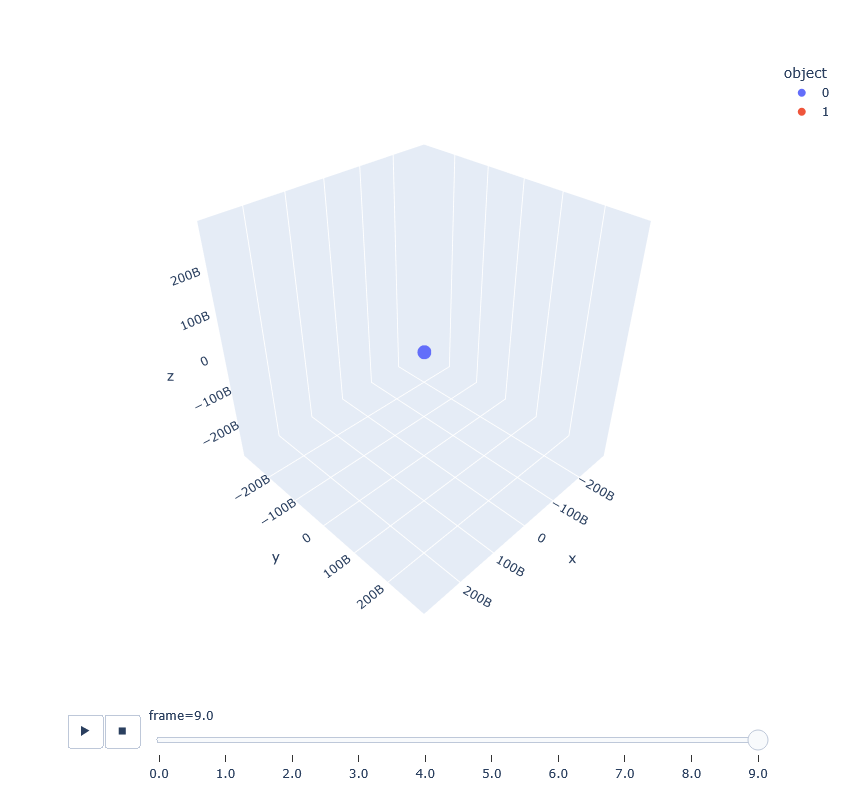

In [4]:
N = 2 #Number of objects
dt = 0.001 #Timestep
s_prime = 3.175*10**(-7)
Time = 100 #Duration of the simulation
frame_skip = 10000 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 6.67*10**(-11)/(s_prime*dt) #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 1.496*10**11

t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 1.989*10**(30)
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((1.496*10**11,0,0))
objects[1,3] = 5.972*10**24
objects[1,4:7] = np.array((0,29785*(5.972*10**24)/(s_prime*dt),0))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-2*R, 2*R]),
        yaxis=dict(range=[-2*R, 2*R]),
        zaxis=dict(range=[-2*R, 2*R]),
        aspectmode='cube'
    )
)

fig.show()

The quesiton that we want to awnser is how does the intial conditions like velocity and mass effect the planetary orbits.

Some assumptions that we have made are that the only force in our system is the force between the two planets, we create the planets as particles meaning there is no rotation in play. We also assumed no friction/drag and that there is no collisions that will happen. Making these assumption would not affect our out come of our rather simple linear model without causing confusions. 


The main physics that is used for this project in the gravitational force equation that being 

$$F = \frac{G m_1 m_2}{r^3} r_0$$

where G is the graviational constant m1 and m2 is the mass of object 1 and 2. r is the distance between our two masses. 
